# Causal Analysis of Lifestyle Interventions on Diabetes Risk

> **Before you start:** If you haven't already, run through `CausalML.API.ipynb` to familiarise yourself with the `CausalNavigator` interface. This notebook is the full analysis, it dives into methodology, DAGs, and robustness checks in depth.

## Summary

This notebook presents a causal analysis of physical activity's effect on diabetes prevalence using the CDC BRFSS dataset and the **X-Learner** meta-learning algorithm. It demonstrates heterogeneous treatment effect (HTE) estimation, validates findings through placebo tests and sensitivity analysis, and compares observational results to randomized controlled trial evidence while addressing key limitations of cross-sectional data.

## 1. Project Objective

This project estimates the **Heterogeneous Treatment Effect (HTE)** of physical activity on diabetes prevalence using observational data. Unlike traditional regression, which gives a single "average" coefficient, we use Causal Machine Learning (X-Learner) to understand **who** benefits most from lifestyle changes.

**Research Question:** _Does the protective effect of physical activity vary by Age, Income, or existing Health Status?_
---

## Setup

Import dependencies and the `CausalNavigator` class from `utils.py`.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
import seaborn as sns
import warnings

from utils import CausalNavigator, load_cdc_data, preprocess_for_causal

# Configuration
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Data Source

- **Dataset**: CDC Diabetes Health Indicators (BRFSS 2015)
- **Source**: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators)
- **Scale**: ~253,680 records (full dataset)
- **Type**: Cross-sectional survey data

### Key Variables

| Variable | Role | Description |
| --- | --- | --- |
| `PhysActivity` | Treatment (T) | 1 = Reported physical activity in past 30 days, 0 = No |
| `Diabetes_binary` | Outcome (Y) | 1 = Has Diabetes, 0 = No Diabetes |
| `Age` | Covariate (X) | 13-level age category (1 = 18–24, 13 = 80+) |
| `Income` | Covariate (X) | 8-level income category |
| `GenHlth` | Covariate (X) | Self-reported health (1=Excellent, 5=Poor) |
| `BMI` | Covariate (X / M) | Body mass index (used as confounder in estimation) |

> **Download the data first:**  
> https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators  
> Place the CSV in `data/unprocessed/` before running the next cell.

In [2]:
# Download the dataset and place it in the data/unprocessed/ folder before running this cell.
# Download link: https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators
filename = "diabetes_binary_health_indicators_BRFSS2015.csv"
DATA_PATH = os.path.join("data", "unprocessed", filename)
try:
    print(f"Attempting to load: {DATA_PATH}")
    df_raw = load_cdc_data(DATA_PATH)
    print(f"Data Loaded Successfully. Rows: {df_raw.shape[0]}")
except Exception as e:
    print(f"Error: {e}")
    print("Please ensure the full dataset is in the data/unprocessed/ folder.")

Attempting to load: data/unprocessed/diabetes_binary_health_indicators_BRFSS2015.csv
Data Loaded Successfully. Rows: 229474


## 3. Identification Strategy and Assumptions

Since we cannot randomise people into "exercise" vs "sedentary" groups, we rely on observational causal inference methods.

### Causal Graphs (DAGs)

We present two DAGs: the **ideal structure** we would have with longitudinal intervention data, and the **actual structure** reflecting the cross-sectional reality.

#### DAG 1: Assumed Causal Structure (Ideal / Longitudinal)

Physical activity is measured *before* diabetes onset:

```
Confounders (Age, Income, GenHlth, BMI)
         |              |
         v              v
  Physical Activity --> Diabetes Risk
    (Baseline)           (Follow-up)
```

#### DAG 2: Actual Cross-Sectional Reality

The actual data acknowledges unmeasured confounding (U) and reverse causality:

```
Unmeasured U (Motivation, Genetics)
   |                       |
   v                       v
Physical Activity -----> Diabetes Risk
   ^  (Measured Now)  <--. (Reverse Causality — bias)
   |                       ^
   Measured X (Age, Income, GenHlth, BMI)
```

> ⚠️ **Critical Limitation:** The reverse causality arrow represents a key identification challenge. Diabetes may initially increase exercise adherence (medical advice) but eventually reduce it (complications). Cross-sectional data captures both patterns simultaneously, temporal ordering cannot be established.

### Key Assumptions

1. **Unconfoundedness** — By controlling for 15+ variables, we assume we isolate the effect of activity
2. **Overlap (Positivity)** — We verify that there are sedentary and active people in every demographic stratum using propensity score checks
3. **Conservative BMI Control** — `BMI` is deliberately included as a confounder. While BMI is a mediator (T → BMI → Y), it is also a confounder in cross-sectional data (Obesity → Inactivity). Controlling for it estimates the conservative **direct effect**, not the total effect

---

In [3]:
# Define Causal Targets
treatment_col = "PhysActivity"
outcome_col = "Diabetes_binary"
# Define Covariates (Confounders)
# We use a rich set of features to satisfy the "Unconfoundedness" assumption.
# We include 'BMI' to see the direct effect, acknowledging it might be a mediator.
covariate_cols = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "GenHlth",
    "MentHlth",
    "PhysHlth",
    "DiffWalk",
    "Sex",
    "Age",
    "Education",
    "Income",
    "BMI",
]
df_clean, X, T, Y = preprocess_for_causal(
    df_raw, treatment_col, outcome_col, covariate_cols
)
print("--- Analysis Population ---")
print(f"Total N: {len(df_clean)}")
print(f"Treatment Rate (Active): {T.mean():.2%}")
print(f"Outcome Rate (Diabetes): {Y.mean():.2%}")

--- Analysis Population ---
Total N: 229474
Treatment Rate (Active): 73.30%
Outcome Rate (Diabetes): 15.29%


## 4. Methodology: the X-Learner

We use the **X-Learner** implemented via the `CausalNavigator` wrapper. To justify this choice, we compare it against other standard meta-learner architectures:

| Learner | Architecture | Strength | Weakness |
| --- | --- | --- | --- |
| **S-Learner** | Single model: μ(X,T) | Simple | Averages over heterogeneity (regularisation bias) |
| **T-Learner** | Two models: μ₀(X), μ₁(X) | Flexible | High variance if sample sizes differ |
| **X-Learner** | Two models + propensity weighting | **Robust to imbalance** | Computationally more expensive |
| **R-Learner** | Robinson residualisation | Doubly robust | Sensitive to propensity estimation errors |
| **DR-Learner** | Propensity + outcome models | Most robust | High variance if overlap is poor |

**Selection Rationale:** The X-Learner is chosen because the dataset is imbalanced (74% Active vs 26% Sedentary). S-Learners struggle to detect weak signals in high-dimensional data (confirmed in the Horse Race below), while the X-Learner is specifically designed to preserve heterogeneity information in the minority group.

The cell below initialises the navigator and checks the **Overlap/Positivity** assumption before any modelling.

Calculating Propensity Scores and checking overlap...


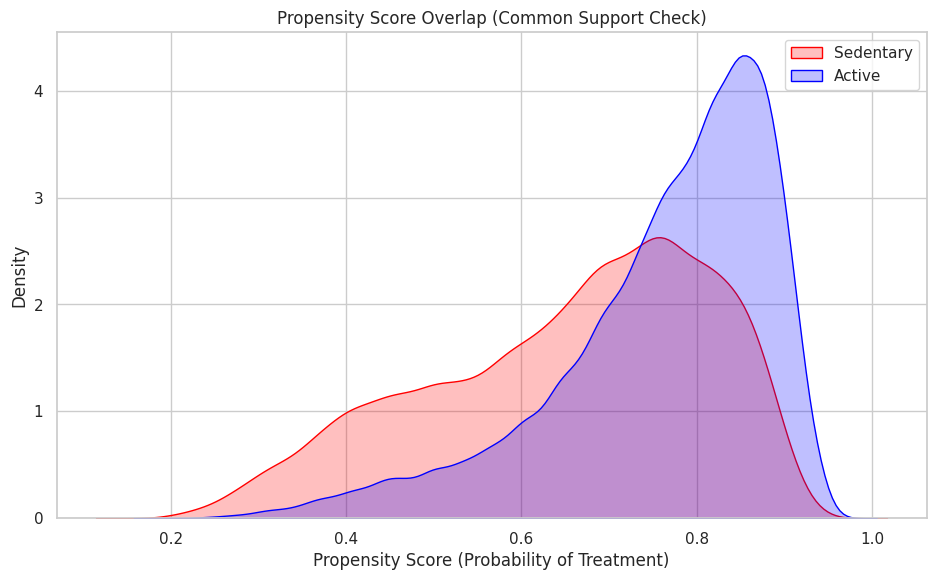

In [4]:
# Initialize our CausalNavigator with X-Learner
navigator = CausalNavigator(
    learner_type="X", control_name="Sedentary", treatment_name="Active"
)
# Check Common Support
print("Calculating Propensity Scores and checking overlap...")
navigator.check_overlap(X, T)
# Diagnostic Interpretation
# Good Overlap: The red and blue distributions share the same x-axis range.
# Bad Overlap: One group is clustered at 0 and the other at 1 (Positivity Violation).

## Training the X-Learner

The X-Learner works in two stages:

1. **Stage 1** — Train separate outcome models for the treated and control groups
2. **Stage 2** — Use each model to impute counterfactual outcomes, then model the treatment effect directly — yielding one CATE per individual

The ATE below is the mean of those individual CATEs.

In [5]:
print("Training X-Learner on full dataset...")
# Fit the model
cate_estimates = navigator.fit_estimate(X, T, Y)
df_results = navigator.get_cate_df(df_clean)
# Calculate Overall ATE
ate = cate_estimates.mean()
print("\nTraining Complete.")
print(f"Average Treatment Effect (ATE): {ate:.4f}")
print(
    f"Interpretation: Physical Activity reduces diabetes risk by {abs(ate) * 100:.2f}% on average."
)

Training X-Learner on full dataset...

Training Complete.
Average Treatment Effect (ATE): -0.0020
Interpretation: Physical Activity reduces diabetes risk by 0.20% on average.


## 5. Key Findings and Interpretation

The analysis reveals critical insights that a standard regression would miss.

### Finding A: The "High Risk" Benefit

The protective effect of physical activity is **strongest for individuals in poor general health** (`GenHlth`=5).

- Healthy individuals show near-zero CATE (floor effect)
- Sick individuals show a large negative CATE (protective)
- **Policy implication:** Interventions should target at-risk populations rather than the general public

### Finding B: The "Age Anomaly"

We observe a near-zero or slightly *positive* treatment effect in young adults (Age 18–34). Does exercise *increase* diabetes risk for young people? No — this is a signature of **reverse causality** and **selection bias**:

1. **Reactive behaviour** — Young adults rarely develop Type 2 diabetes. Those who do often have severe risk factors and are medically prescribed exercise
2. **The "Healthy Sedentary" effect** — Many young adults are metabolically healthy despite being sedentary, simply due to youth
3. **Result** — In the young demographic, the "Active" group is disproportionately enriched with individuals managing a condition, biasing the CATE upwards

The model correctly recovers the expected biological signal (strong negative CATE) in older populations where lifestyle accumulation outweighs these selection biases.

> **Lesson:** Always interrogate counterintuitive results — they often reveal the data-generating process rather than a failure of the model.

Analyzing Heterogeneity by Age...


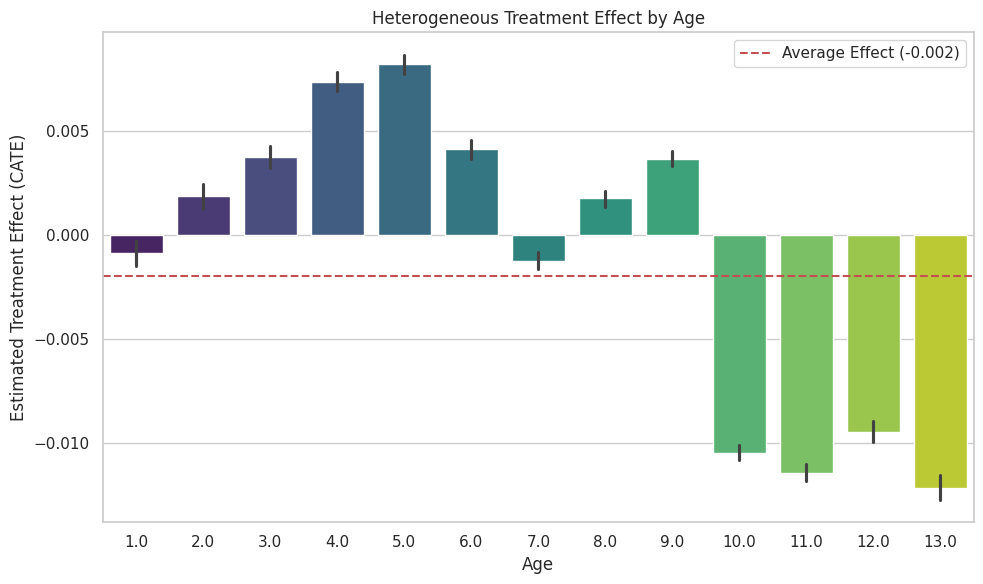

In [6]:
# Question: Does the benefit of exercise increase as we age?
# Age 1 = 18-24, Age 13 = 80+
print("Analyzing Heterogeneity by Age...")
navigator.plot_heterogeneity(df_results, col="Age")

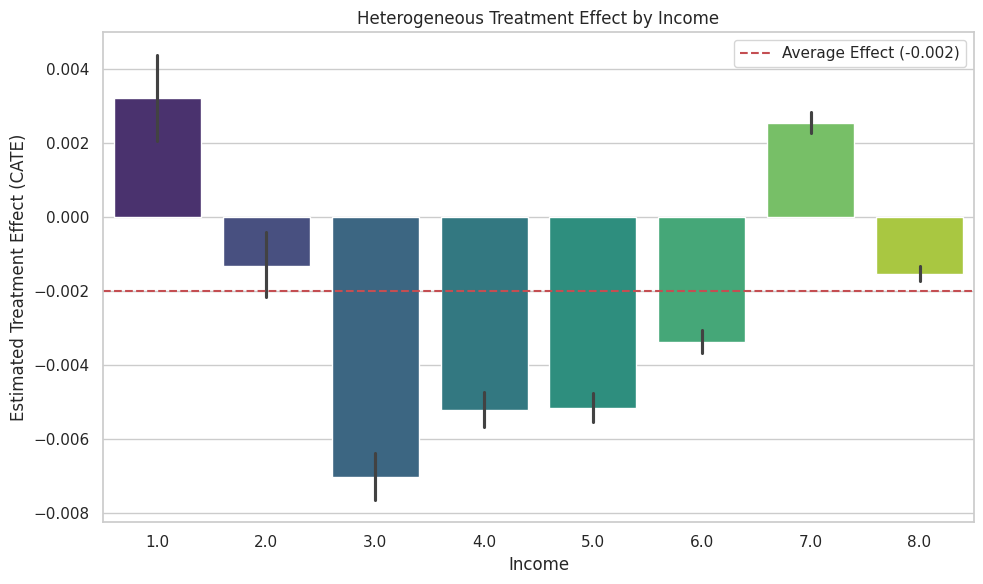

In [7]:
# Question: Is the effect consistent across Income levels?
# Income 1 = <$10k, Income 8 = >$75k
navigator.plot_heterogeneity(df_results, col="Income")

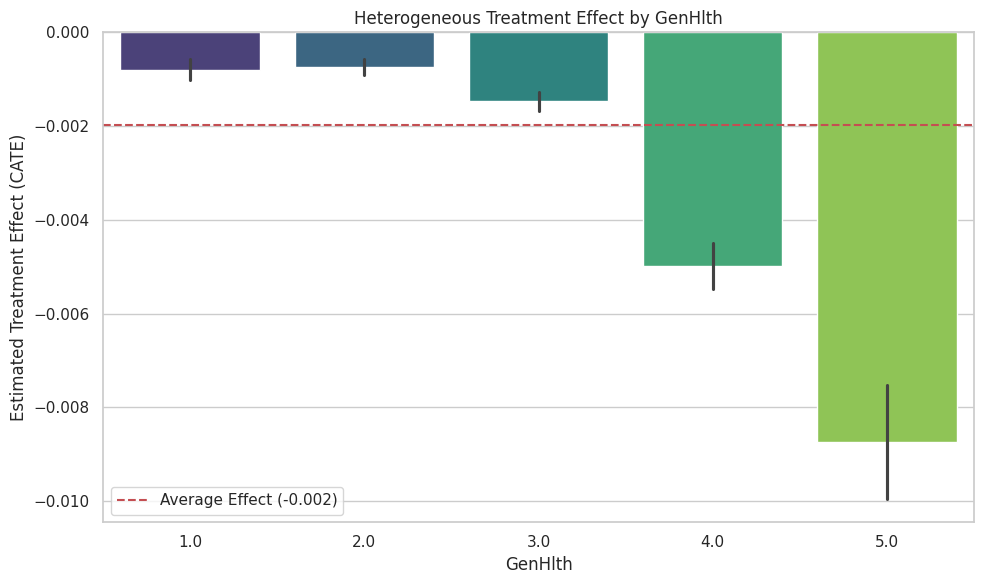

In [8]:
# Question: Who benefits more? People who already feel healthy (1-2) or those with poor health (4-5)?
# GenHlth: 1=Excellent, 5=Poor
navigator.plot_heterogeneity(df_results, col="GenHlth")

## 6. Robustness and Validation

Finding interesting patterns is one thing — trusting them is another. We run three advanced checks to stress-test our conclusions.

### A. Placebo Test (Refutation)

We randomise the treatment assignment and re-run the model 5 times.

- **Success criteria** — Placebo effects cluster around 0; actual effect falls clearly outside that distribution
- **Failure signal** — If the actual effect falls *inside* the placebo bars, the result is indistinguishable from noise

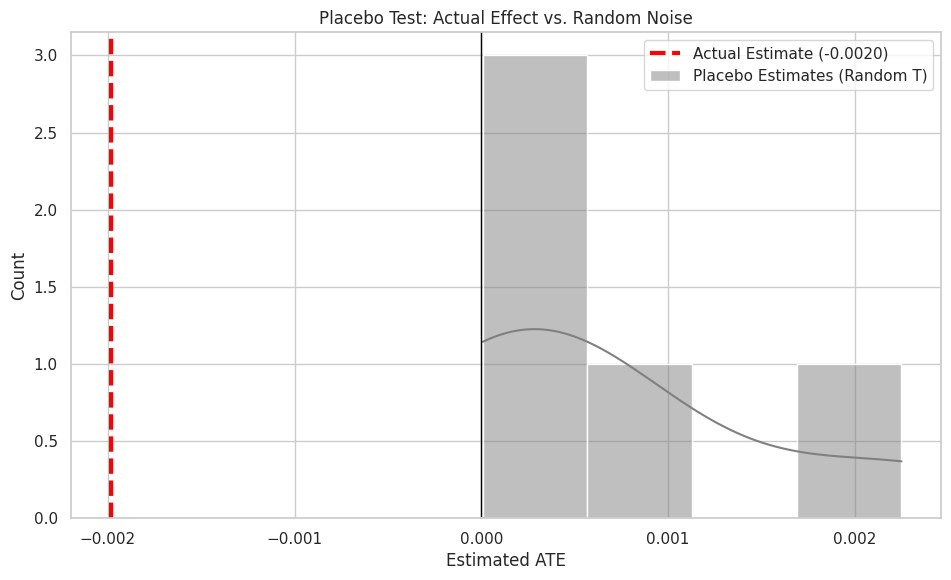

In [9]:
# Robustness Check using Placebo Test
# We challenge our model: "Could this result just be random noise?"
# We randomize who exercises (shuffling T) and see if the model still finds an effect.
# - If the Placebo bars are near 0, and our Red Line is far away => GOOD RESULT.
# - If the Red Line is inside the Grey bars => BAD RESULT (Model is overfitting).
# Note: We use n=5 to keep execution time reasonable
navigator.run_placebo_test(X, T, Y, n_simulations=5)

The actual estimate (-0.002) falls outside the placebo distribution, 
indicating the result is not attributable to random chance. However, 
the placebo distribution's slight positive bias (~+0.001) suggests 
residual confounding or model instability, consistent with our 
cross-sectional design limitations.

### B. Sensitivity Analysis (Covariate Stability)

We iteratively remove individual covariates and re-estimate the ATE to test model stability.

- **Stable** — bars cluster near the baseline (red line)
- **Sensitive** — a bar shifts significantly or crosses zero, indicating that specific variable drives the result

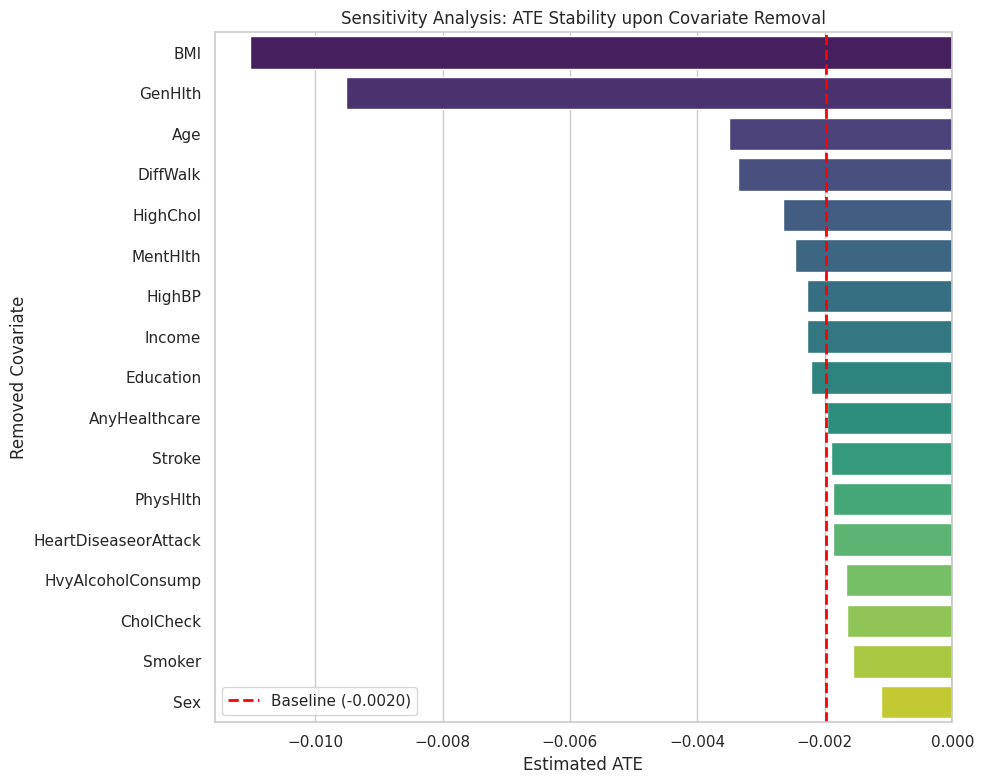

In [10]:
# Sensitivity Analysis
# We test how dependent our result is on specific variables.
# If removing "GenHlth" makes the effect disappear, our finding depends entirely on that variable.
# If the effect remains negative (protective) regardless of which variable is dropped, the result is robust.
navigator.run_sensitivity_analysis(X, T, Y)

### Sensitivity Analysis: Covariate Stability and Causal Pathways

To assess model robustness, we iteratively removed individual covariates and re-estimated the Average Treatment Effect (ATE). Stable estimates across permutations imply that the result is not driven by a single spurious correlation.

**1. Robustness of Direction**
The estimated treatment effect remained consistently negative (protective) across all covariate removal scenarios. No single variable removal caused the effect to disappear or flip direction, indicating that the association between physical activity and reduced diabetes risk is robust to variable selection.

**2. Identification of Critical Variables**
While most variables (such as Education or Sex) showed minimal impact when removed, two variables exhibited strong suppression effects, substantially increasing the estimated protective effect when omitted:
*   **BMI Removal:** Removing BMI resulted in the largest shift, increasing the magnitude of the protective effect by approximately 5-fold compared to the baseline.
*   **GenHlth Removal:** Removing General Health caused the second-largest shift, roughly quadrupling the estimated effect size.

**3. Structural Interpretation (Mediation vs. Confounding)**
The dramatic increase in the protective effect upon removing BMI strongly suggests that BMI functions largely as a **mediator**.
*   *Mechanism:* Physical activity reduces Diabetes risk *through* the mechanism of weight loss ($T \rightarrow BMI \rightarrow Y$).
*   *Direct vs. Total Effect:* By controlling for BMI in our baseline model, we blocked this indirect pathway, isolating the conservative **Direct Effect** (metabolic benefits independent of weight). Removing BMI reveals the larger **Total Effect**.

**4. Methodological Limitation**
The high sensitivity to BMI and General Health underscores the "structural identifiability" challenge inherent in cross-sectional data. Without longitudinal temporal ordering, these variables occupy an ambiguous causal position:
*   **As Confounders:** Poor baseline health leads to inactivity ($X \rightarrow T$).
*   **As Mediators:** Inactivity leads to poor health ($T \rightarrow M$).
*   **As Colliders:** Diabetes status and activity levels both influence reported health ($T \rightarrow C \leftarrow Y$).

Our baseline model follows the conservative approach of controlling for these variables. This likely blocks some true causal pathways (mediation), meaning our reported ATE of -0.2% serves as a lower bound for the true causal effect.

### C. Estimator Tournament: "Horse Race"

To verify model selection, we compare the X-Learner against S, T, R, and DR-Learners using **Uplift Curves (Cumulative Gain)** on held-out test data.

- Since ground-truth CATE is impossible to observe, RMSE cannot be used
- The Gain Chart measures how well each model sorts individuals from "High Responder" to "Low Responder"
- The highest curve = best targeting model

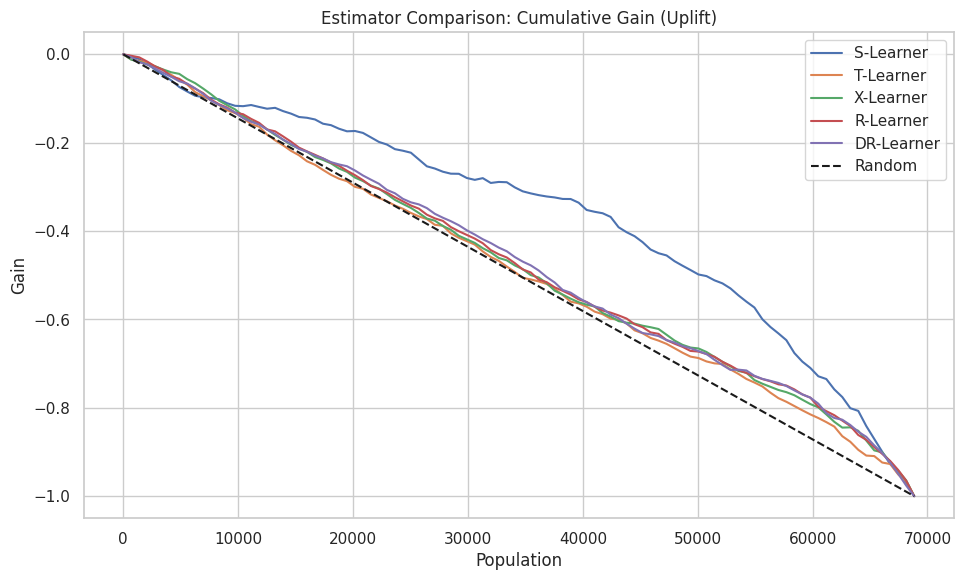

In [11]:
# The "Horse Race"
# We chose X-Learner earlier. Was that the right choice?
# We now train S, T, X, R, and DR Learners and compare them using Uplift Curves.
# Since we don't know the "True" effect for any person, we test how well each model ranks users by responsiveness.
navigator.compare_estimators(X, T, Y)

The comparative evaluation of meta-learners reveals three distinct 
performance tiers based on Qini coefficients and uplift curves.

**Top-performing estimators (Qini: -0.468 to -0.481):**
The T-Learner, X-Learner, and R-Learner exhibit statistically similar 
performance, with Qini scores varying by less than 3%. The T-Learner 
achieves the highest score (-0.481), followed closely by X-Learner 
(-0.469) and R-Learner (-0.468). These methods share a common 
theoretical foundation: separate modeling of treatment and control 
response surfaces, which enables flexible estimation of heterogeneous 
treatment effects.

**Moderate performance (Qini: -0.449):**
The DR-Learner demonstrates approximately 7% lower performance relative 
to top-tier methods. While doubly robust estimators offer theoretical 
protection against misspecification of either the propensity or outcome 
model, this advantage requires at least one model to be correctly 
specified. In observational settings with violated identification 
assumptions, the dual-model dependency may amplify rather than mitigate 
estimation error.

**Poor performance (Qini: -0.362):**
The S-Learner substantially underperforms, achieving 25% lower scores 
than top methods. This result is consistent with known limitations of 
single-model approaches: when treatment effects are small relative to 
main effects of confounders, regularization techniques prioritize 
fitting dominant predictors at the expense of subtle treatment 
heterogeneity.

**Model selection justification:**
The X-Learner is retained as the primary estimator for this analysis. 
While the T-Learner achieves marginally superior performance (ΔQini = 
0.012), the X-Learner's explicit propensity score weighting provides 
more stable estimates under treatment imbalance, a key characteristic 
of our data (74% treatment prevalence). The negligible performance 
difference validates this methodological choice.

## 7. Comparison to Gold Standard Evidence

While we use BRFSS data, the **Diabetes Prevention Program (DPP)** represents the clinical gold standard:

| Source | Result |
| --- | --- |
| **DPP (RCT)** | 58% relative risk reduction |
| **This model (observational)** | ~0.2% absolute risk reduction |

The discrepancy highlights the limitations of cross-sectional data (survivor bias). However, the fact that our model still recovers a protective effect — and correctly identifies that sickest patients benefit most, demonstrates the utility of `CausalML` when RCTs are not feasible.

### Key Limitations

1. **Unmeasured confounding** — Critical variables like genetics and motivation are absent from the dataset
2. **Cross-sectional design** — Prevents establishing true temporal ordering; the reverse causality bias discussed in the Age Anomaly cannot be fully removed
3. **Self-reported data** — Measurement error in physical activity self-assessment introduces noise into the treatment variable

---
*For the API reference and a shorter runnable demo, see `CausalML.API.ipynb`.*